<a href="https://colab.research.google.com/github/dagmaros27/AIMS_Notebooks/blob/main/GP_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import matplotlib
%matplotlib inline
from IPython.display import display, Math
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Set higher DPI and figure quality for all plots
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = 'white'

# Sampling from a Gaussian process

Let us assume that some field $x(t)$ follows a Gaussian process i.e.

$$ x(t) \sim \mathcal{GP}(m(t), k(t, t')).  $$

How can we draw samples of $x$ at arbitrary points in the domain $t \in \mathbb{R}$?

/tmp/ipykernel_341/3144963519.py:11: RuntimeWarning: invalid value encountered in sqrt
  return sigmaf**2 *(1 + np.sqrt(3*(t-tp))/l) * np.exp(-1 * np.sqrt(3*(t-tp))/ l)


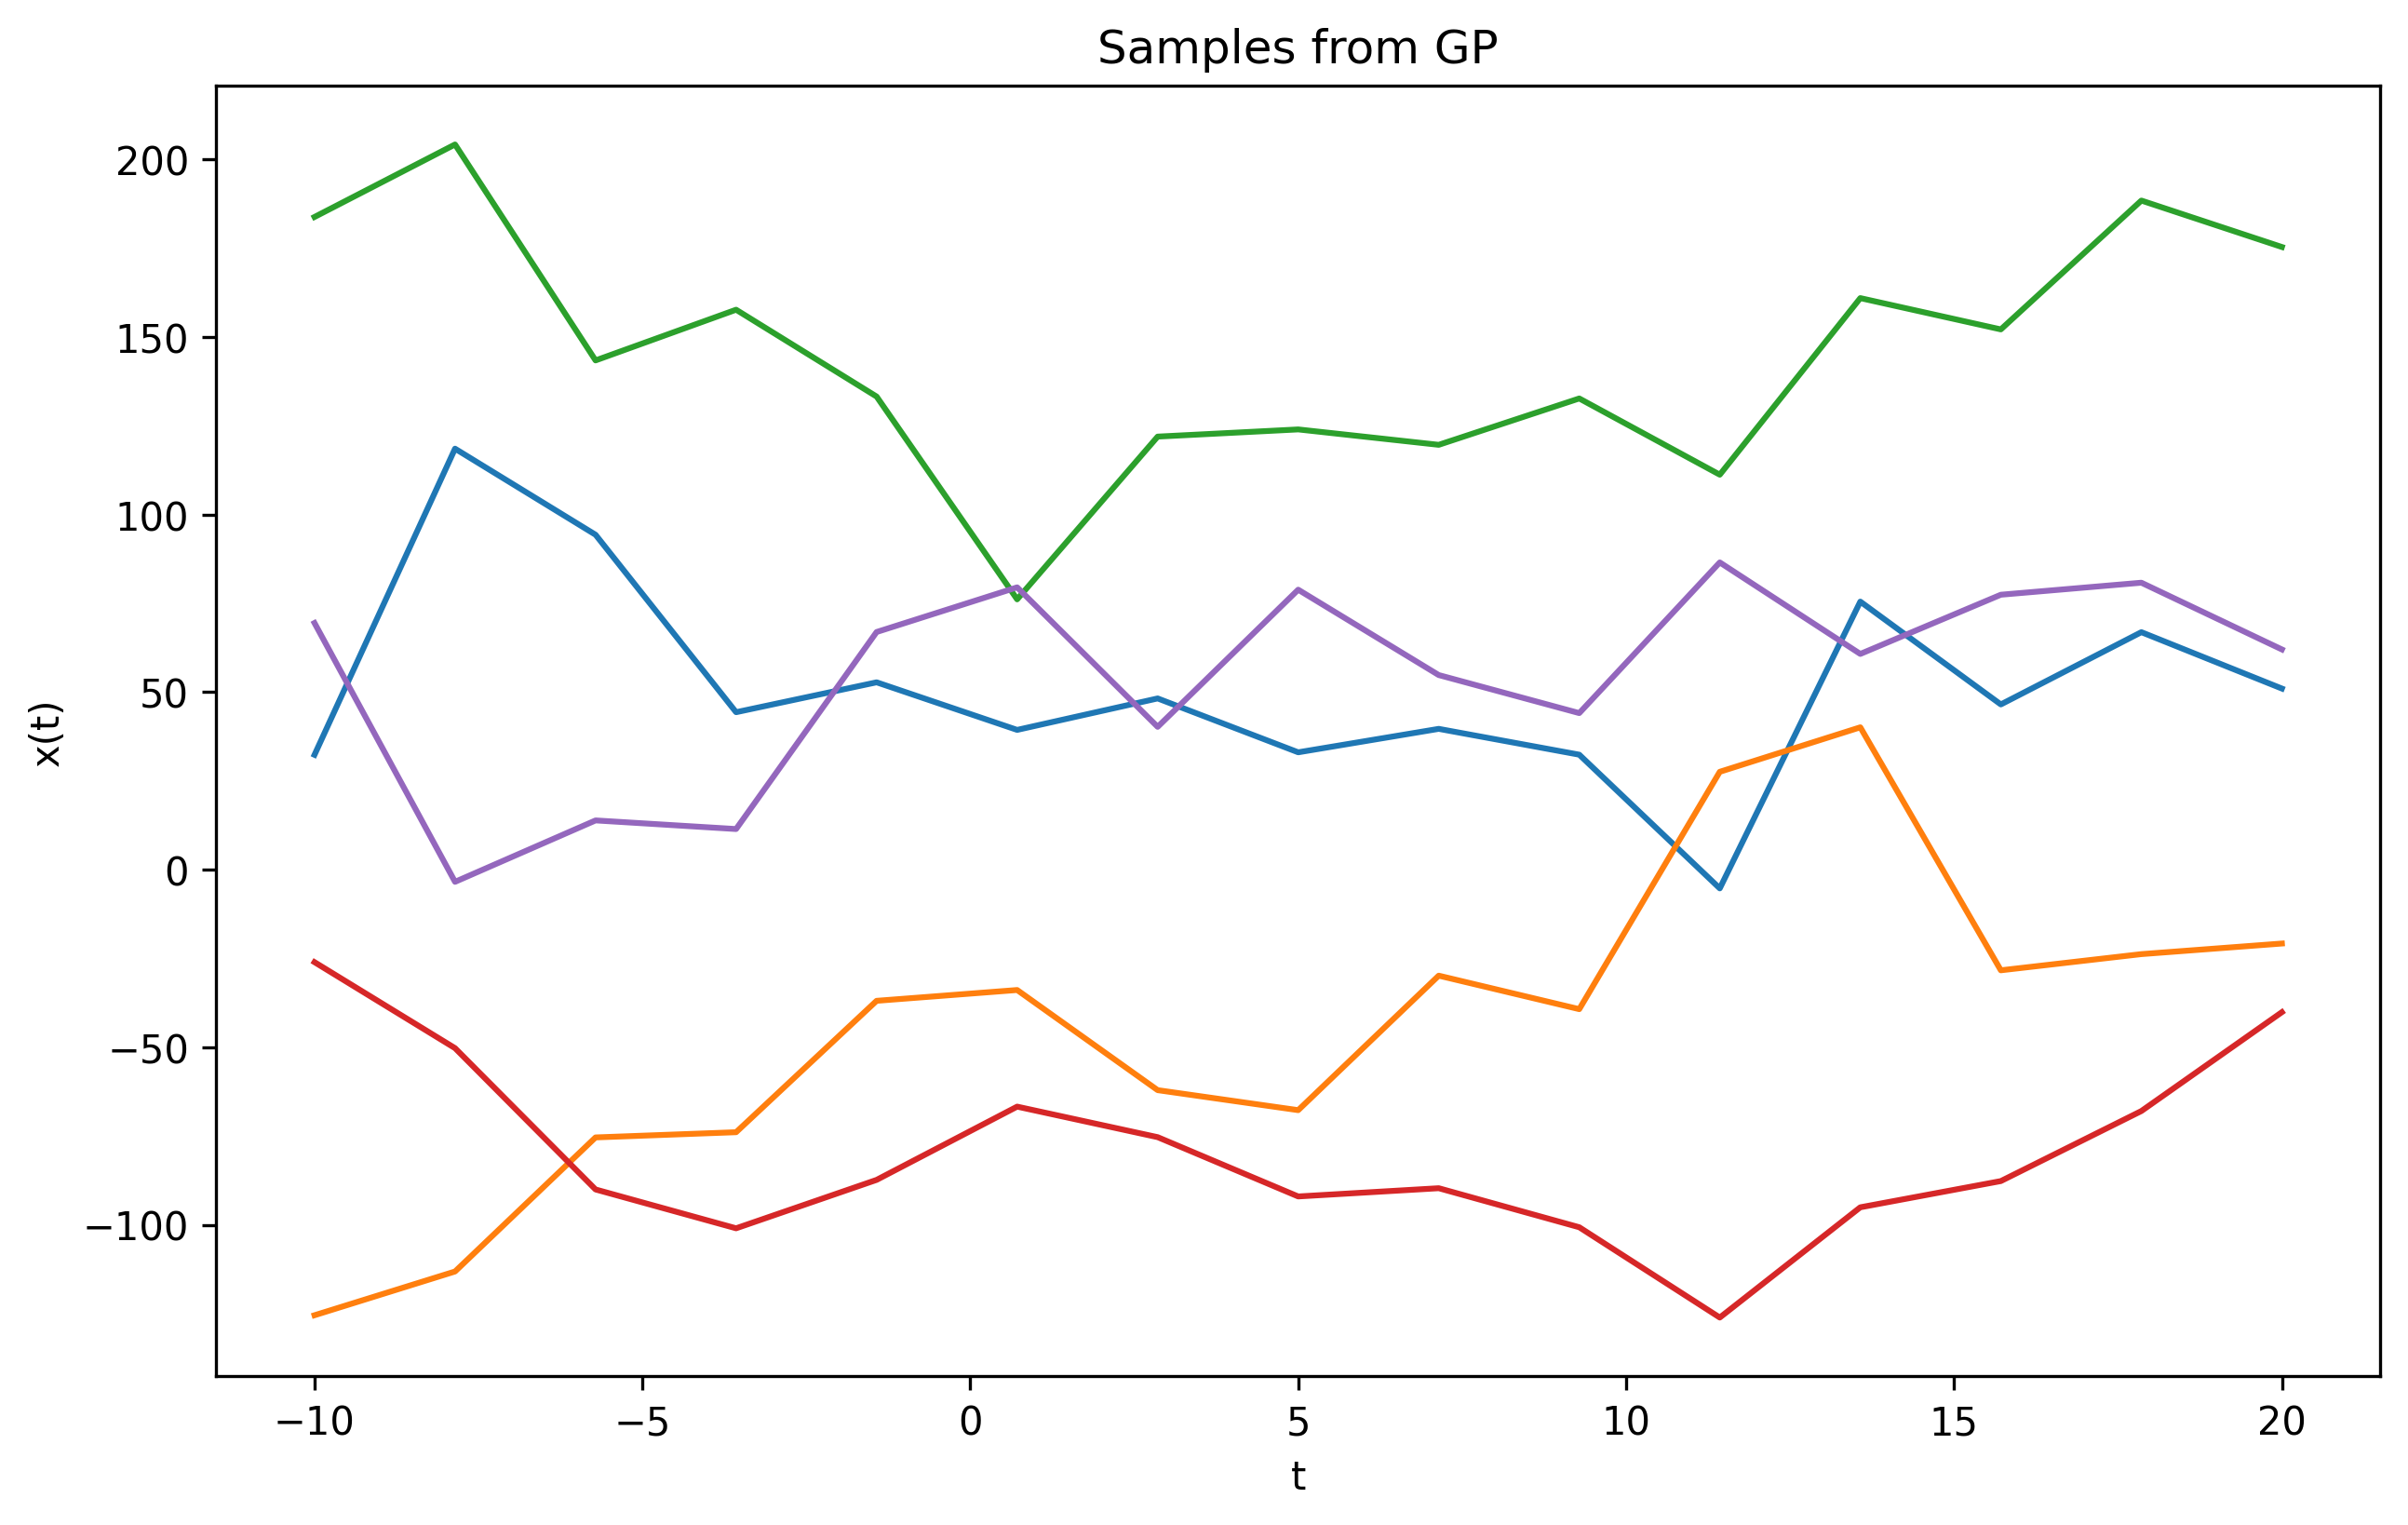

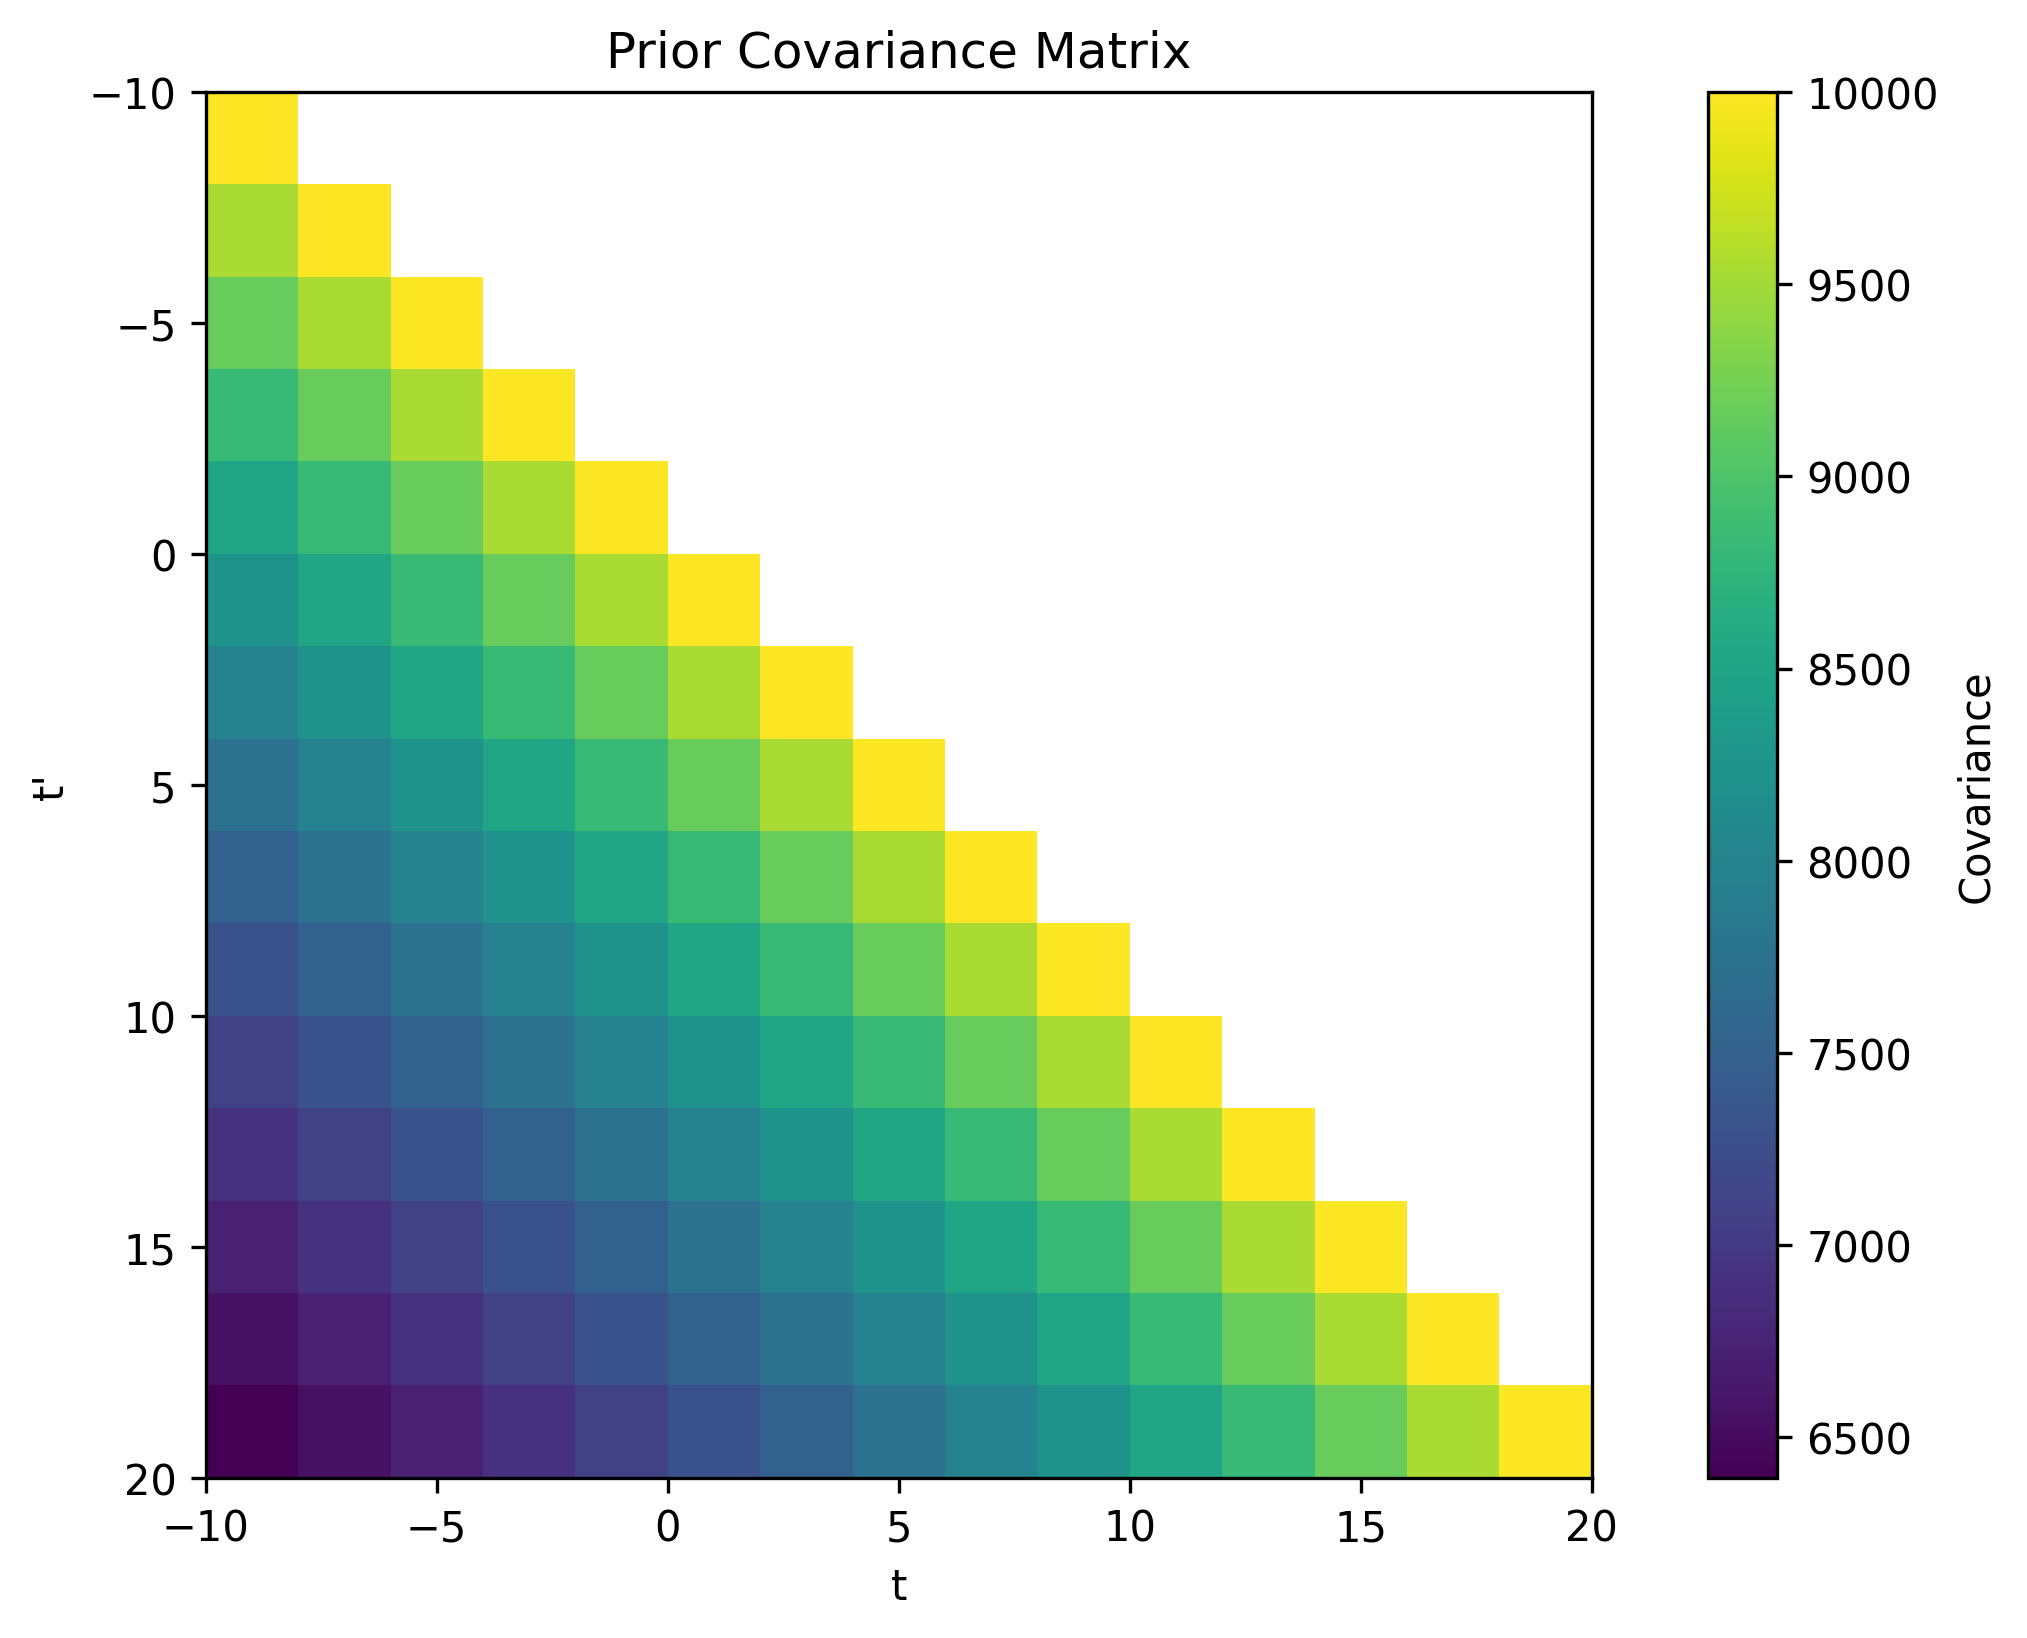

In [7]:
# choose a random domain
nt = 15
t = np.linspace(-10, 20, nt)

# define mean and covariance functions
def mean(t):
    return np.zeros(t.shape)  # zero mean

# squared exponential covariance function
def sqexp(t, tp, sigmaf, l):
    return sigmaf**2 *(1 + np.sqrt(3*(t-tp))/l) * np.exp(-1 * np.sqrt(3*(t-tp))/ l)


# now we can construct the covariance matrix
sigmaf = 100.0
l = 7.5
K = np.zeros((nt, nt))
for i in range(nt):
    for j in range(nt):
        K[i, j] = sqexp(t[i], t[j], sigmaf, l)

# to draw samples we compute a Cholesky decomposition of the covariance matrix
L = np.linalg.cholesky(K + 1e-8*np.eye(nt))  # note the jitter term for numerical stability

# draw samples
n_samples = 5
f = mean(t)[:, None] + np.dot(L, np.random.randn(nt, n_samples))

# plot samples
plt.figure()
plt.plot(t, f)
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Samples from GP')
plt.show()

# plot the prior covariance matrix
plt.figure()
plt.imshow(K, extent=(t[0], t[-1], t[-1], t[0]))
plt.colorbar(label='Covariance')
plt.xlabel('t')
plt.ylabel('t\'')
plt.title('Prior Covariance Matrix')
plt.show()

# 1) - try altering the hyper-parameter values and see how the samples change
# 2) - try altering the mean function and see how the samples change
# 3) - try altering the covariance function and see how the samples change
# 4) - try altering the domain and see how the samples change
# 5) - what structure do you notice in the prior covariance matrix and how do you think we can exploit this structure?

# Gaussian process denoising

Given observations (dropping $t$ for simplicity)

$$ y = x + \epsilon, ~~ \epsilon \sim \mathcal{N}(0, \Sigma)  $$

we know that the likelihood for the problem takes the form

$$ p(y | x) = \frac{1}{\sqrt{(2\pi)^n |\Sigma|}} \exp\left(-\frac{1}{2}(y - x)^\dagger \Sigma^{-1} (y - x) \right). $$

We can also assume a Gaussian process prior on $x$ which, assuming a zero mean function, would take the form

$$ p(x) = \frac{1}{\sqrt{(2\pi)^n |K|}} \exp\left(-\frac{1}{2}x^\dagger K^{-1} x \right). $$

By Bayes' law, the posterior is given by the product of the likelihood and prior (up to a normalisation constant). We also know that this must have the form of a Gaussian so the term in the exponent of the posterior must, at least up to some constant $C$, be proportional to

$$ (x - \bar{x})^\dagger D^{-1} (x - \bar{x})  $$

where $\bar{x}$ is the posterior mean and $D$ is the posterior covariance. Expanding we find

$$ x^\dagger D^{-1} x - 2 x^\dagger D^{-1} \bar{x} + \bar{x}^\dagger D^{-1} \bar{x} + C  $$

where the factor of $2$ stems from the fact that $x^\dagger D^{-1} \bar{x} = \bar{x}^\dagger D^{-1} x$ since the term is a real scalar and we have included the constant $C$ for completeness. Also expanding the terms in the exponent of the (-log) likelihood times (-log) prior gives

$$ (y - x)^\dagger \Sigma^{-1} (y - x) + x^\dagger K^{-1} x = x^\dagger \left(\Sigma^{-1} + K^{-1}\right) x - 2 x^\dagger \Sigma^{-1} y + y^\dagger \Sigma^{-1} y $$

Now we can read off the unknowns by comparing coefficients. First, from the quadratic term, we have

$$ D^{-1} = \Sigma^{-1} + K^{-1}  $$

which is the sought after posterior covariance matrix. We can find its inverse in a numerically stable way using the matrix inversion lemma

$$ D = \Sigma - \Sigma (K + \Sigma)^{-1} \Sigma = \Sigma - \Sigma K^{-1}_y \Sigma, $$

where we have labelled $K_y = K + \Sigma$ for convenience.

Next, by comparing coefficients for the linear term, we find the posterior mean as

$$ D^{-1}\bar{x} = \Sigma^{-1} y ~~ \rightarrow ~~  \bar{x} = D \Sigma^{-1} y = (I - \Sigma K^{-1}_y) y = y - \Sigma K_y^{-1} y.   $$

So let's see how this works in practice. Let's first simulate some data.

In [ ]:
# choose a random domain
n = 75
ti = 10*np.sort(np.random.rand(n))  # does not have to be sorted

# now we make up some complicated function that we want the Gaussian Process to model
def func(t):
    return 0.25*t**2 + 10*np.sin(t)

x_true = func(t)

# add some noise
sigma_n = 2.0
noise = sigma_n* np.random.randn(n)
y = func(ti) + noise

# plot the noisy data
plt.plot(t, x_true, 'k')
plt.errorbar(ti, y, yerr=sigma_n, fmt='xr', label='data')

In [ ]:
# we choose some arbitrary hyper-parameters to start with
sigmaf = 1.0
l = 1.0

# recompute the kernel on the new domain
K = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        K[i, j] = sqexp(ti[i], ti[j], sigmaf, l)

# construct the noise covariance matrix
Sigma = np.eye(n) * sigma_n**2
Sigma_inv = np.eye(n)/sigma_n**2  # because it is diagonal

# now we can compute the posterior mean and covariance
K_y = K + Sigma
# this is not always numerically stable (see use of SVD below)
xbar = y - Sigma.dot(np.linalg.solve(K_y, y))
D = Sigma - Sigma.dot(np.linalg.solve(K_y, Sigma))

# let's plot the posterior mean and covariance
plt.plot(t, x_true, 'k', label='true function')
plt.plot(ti, xbar, 'b', label='posterior mean')
plt.fill_between(ti, xbar - np.sqrt(np.diag(D)), xbar + np.sqrt(np.diag(D)), color='b', alpha=0.2, label='posterior std')
plt.legend()

# and the covariance matrix
plt.figure()
plt.imshow(D, extent=(ti[0], ti[-1], ti[-1], ti[0]))
plt.colorbar(label='Covariance')
plt.xlabel('t')
plt.ylabel('t\'')
plt.title('Posterior Covariance Matrix')
plt.show()

# 1) - try altering the hyper-parameter values and see how the posterior changes
# 2) - try altering the noise level and see how the posterior changes
# 3) - draw samples from the posterior and plot them
# 4) - does the posterior covariance matrix share the same structure as the prior covariance matrix?

# Hyper-parameter tuning

Clearly the posterior depends on the values of the hyper-parameters. These hyper-parameters must be tuned by maximising the marginal likelihood. The negative log of the marginal likelihood is given (up to some constants) by

$$ -\log p(y | \theta) = y^\dagger K_y^{-1} y + \log |K_y|, $$

note how we have encoded the implicit dependence on the hyper-parameters $\theta = [\sigma_f, l, \sigma_n]$ as a conditional distribution (strictly speaking we should also encode the dependence on the training points $t$ but we omit this for convenience). Training consists of minimising this function with respect to $\theta$. We'll do this with one of scipy's optimisation routines.   

In [ ]:
# since we'll be evaluating this function many times we provide a more efficient implementation
def sqexp2(r, sigmaf, l):  # here r = |t - tp|
    return sigmaf**2 * np.exp(-0.5 * r**2 / l**2)

tdiffs = np.abs(ti[:, None] - ti[None, :])

def marginal_likelihood(theta, y, tdiffs):
    n = y.size
    sigmaf = theta[0]
    l = theta[1]
    Ky = sqexp2(tdiffs, sigmaf, l) + np.eye(n)*theta[2]**2
    u, s, v = np.linalg.svd(Ky, hermitian=True)
    logdetK = np.sum(np.log(s))
    Kyinv = u.dot(v/s.reshape(n, 1))
    alpha = Kyinv.dot(y)
    return np.vdot(y, alpha) + logdetK


# choose initial guess for hyper-parameters
theta0 = np.array([1.0, 1.0, 1.0])
res = minimize(marginal_likelihood, theta0, args=(y, tdiffs), bounds=[(1e-3, None), (1e-3, None), (1e-3, None)])
print(res)

In [ ]:
# we recompute the posterior mean and covariance using optimized hyper-parameters
theta = res.x
sigmaf = theta[0]
l = theta[1]
Sigma = np.eye(n) * theta[2]**2
Ky = sqexp2(tdiffs, sigmaf, l) + Sigma
u, s, v = np.linalg.svd(Ky, hermitian=True)
Kyinv = u.dot(v/s.reshape(n, 1))
xbar = y - Sigma.dot(Kyinv.dot(y))
D = Sigma - Sigma.dot(Kyinv.dot(Sigma))

# let's plot the posterior mean and covariance
plt.plot(t, x_true, 'k', label='true function')
plt.plot(ti, xbar, 'b', label='posterior mean')
plt.fill_between(ti, xbar - np.sqrt(np.diag(D)), xbar + np.sqrt(np.diag(D)), color='b', alpha=0.2, label='posterior std')
plt.legend()

# Gaussian Process Regression (GPR)

The lecture ended with the following prescription for doing GPR:

1. Gaussian process prior + Bayes gives posterior (at training inputs).
2. Marginal likelihood used to adapt prior to data.
3. Form joint distribution of data and GP at prediction (testing) points.
4. Use properties of Gaussian to form the conditional distribution at testing points.

We have already performed the first two steps so let's pick up from there.

Recall that the aim of GPR is to provide a posterior for the function $x(t)$ at any value in the domain $t$. Our procedure already yielded the posterior at the initial input (or training) points. All that is left to do is to use the hyper-parameters inferred above to find the posterior at some other output (or prediction) points, which we denote as $t_p$. One way to do this is to form the joint distribution of the data and the field $x(t)$ at the output points viz. $x_p = x(t_p)$. We already have the ingredients to populate the diagonal blocks of the joint density viz.

$$ \begin{bmatrix} y \\ x_p \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} 0 \\ 0 \end{bmatrix}, \begin{bmatrix} K_y & ??? \\ ??? & K_{pp}  \end{bmatrix}  \right),  $$

where $K_{pp}$ is the prior covariance matrix of the field at the output points. To complete the joint density, we need a way to populate the off diagonal blocks of the joint covariance matrix. This can be done simply by evaluating the covariance function at all pairs of input and prediction points (why?). Denoting the matrix formed in this way by $K_p$, we have

$$ \begin{bmatrix} y \\ x_p \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} 0 \\ 0 \end{bmatrix}, \begin{bmatrix} K_y & K_p^\dagger \\ K_p & K_{pp}  \end{bmatrix}  \right).  $$

This allows us to compute the conditional density $p(x_p | y)$ as

$$ \bar{x}_p = K_p^\dagger K_y^{-1}y,  $$
$$ D_p = K_{pp} - K_p^\dagger K_y^{-1} K_p. $$

So let's see how this works.

In [ ]:
# decide on a new domain
m = 1000
tp = np.linspace(-10, 20, m)

# compute the covariance between the new domain and the old domain
Kp = np.zeros((m, n))
for i in range(m):
    for j in range(n):
        Kp[i, j] = sqexp(tp[i], ti[j], sigmaf, l)

# compute the covariance between the new domain
Kpp = np.zeros((m, m))
for i in range(m):
    for j in range(m):
        Kpp[i, j] = sqexp(tp[i], tp[j], sigmaf, l)

# compute the posterior mean and covariance on the new domain
xbarp = Kp.dot(Kyinv.dot(y))
Dp = Kpp - Kp.dot(Kyinv.dot(Kp.T))


# let's plot the posterior mean and covariance on the new domain
plt.plot(t, x_true, 'k', label='true function')
# plt.plot(ti, xbar, 'b', label='posterior mean')
# plt.fill_between(ti, xbar - np.sqrt(np.diag(D)), xbar + np.sqrt(np.diag(D)), color='b', alpha=0.2, label='posterior std')
plt.plot(tp, xbarp, 'b', label='posterior mean (new domain)')
plt.fill_between(tp, xbarp - np.sqrt(np.diag(Dp)), xbarp + np.sqrt(np.diag(Dp)), color='b', alpha=0.2, label='posterior std (new domain)')
plt.errorbar(ti, y, yerr=sigma_n, fmt='xr', label='data')
plt.legend()

# 1) - what's happening at the boundaries of the new domain?
# 2) - try altering the number of data points and see how the posterior changes
# 3) - try altering the hyper-parameters and see how the posterior changes
# 4) - try altering the noise level and see how the posterior changes
# 5) - try altering the domain and see how the posterior changes
# 6) - draw samples from the posterior on the new domain and plot them
# 7) - try altering the covariance function and see how the posterior changes
# 8) - how would you incorporate a non-zero mean function into the regression equations?